# Mutation Score Prediction — Modeling, Evaluation, and Discussion

**Fairuz Bilquis Khan**

This notebook trains and evaluates supervised models on the per-method mutation-score dataset prepared in `eda_preprocessing.ipynb`. The task is multi-class classification of testability (`low`, `medium`, `high`) from static code and control-flow features.

The notebook is organized as follows:

- **Section 3** — model training with two cross-validation strategies (5-fold and GroupKFold by class)
- **Section 4** — evaluation results, confusion matrices, feature importance, cross-project transfer
- **Section 5** — discussion, limitations, and future work

## Setup

In [55]:
import warnings
warnings.filterwarnings("ignore")

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.model_selection import StratifiedKFold, GroupKFold, cross_val_predict, GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

SEED = 42
np.random.seed(SEED)

## Loading the Preprocessed Dataset

Load the feature matrix and target produced by the preprocessing notebook. We keep both unscaled and scaled versions: tree-based models (Random Forest, AdaBoost, Decision Tree) are insensitive to scale, while KNN and the MLP are not.

In [56]:
PREP_DIR = Path("preprocessed")

X_unscaled = pd.read_csv(PREP_DIR / "X_unscaled.csv")
X_scaled   = pd.read_csv(PREP_DIR / "X_scaled.csv")
y          = pd.read_csv(PREP_DIR / "y.csv").squeeze()
groups     = pd.read_csv(PREP_DIR / "groups.csv").squeeze()

with open(PREP_DIR / "metadata.json") as f:
    meta = json.load(f)

CLASS_TO_INT = meta["class_to_int"]
INT_TO_CLASS = {v: k for k, v in CLASS_TO_INT.items()}
CLASS_NAMES  = [INT_TO_CLASS[i] for i in sorted(INT_TO_CLASS.keys())]

print(f"X_unscaled: {X_unscaled.shape}")
print(f"X_scaled:   {X_scaled.shape}")
print(f"y:          {y.shape}, class counts = {dict(y.value_counts().sort_index().rename(index=INT_TO_CLASS))}")
print(f"groups:     {groups.shape}, {groups.nunique()} unique class_fqn values")

X_unscaled: (3872, 32)
X_scaled:   (3872, 32)
y:          (3872,), class counts = {'low': np.int64(1250), 'medium': np.int64(1374), 'high': np.int64(1248)}
groups:     (3872,), 118 unique class_fqn values


## 3. Model Training

### 3.1 Models

Six supervised models are trained on the dataset. The hyperparameter values below are reasonable defaults; modest tuning is applied during evaluation. Class weight balancing is enabled where supported, to compensate for the imbalanced target distribution observed during EDA.

In [57]:
MODELS = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=12, min_samples_leaf=5, class_weight="balanced", random_state=SEED,
    ),
    "KNN (k=15)": KNeighborsClassifier(
        n_neighbors=15, weights="distance",
    ),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=None, min_samples_leaf=2,
        class_weight="balanced", n_jobs=-1, random_state=SEED,
    ),
    "AdaBoost": AdaBoostClassifier(
        n_estimators=200, learning_rate=0.5, random_state=SEED,
    ),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(64, 32), max_iter=500,
        early_stopping=True, random_state=SEED,
    ),
}

# Tree-based models receive unscaled features; the rest receive scaled.
USE_SCALED = {"Decision Tree": False, "KNN (k=15)": True, "Naive Bayes": True,
              "Random Forest": False, "AdaBoost": False, "MLP": True}

print(f"{len(MODELS)} models defined:")
for name in MODELS:
    print(f"  - {name}  (scaled inputs: {USE_SCALED[name]})")

6 models defined:
  - Decision Tree  (scaled inputs: False)
  - KNN (k=15)  (scaled inputs: True)
  - Naive Bayes  (scaled inputs: True)
  - Random Forest  (scaled inputs: False)
  - AdaBoost  (scaled inputs: False)
  - MLP  (scaled inputs: True)


### 3.2 Baselines

Three baselines are evaluated to establish a meaningful comparison floor. A model that does not beat these baselines has not learned anything useful.

- **Majority class**: always predicts the most frequent class. Tests whether the dataset is even discriminable.
- **LOC-only**: a decision tree using only `loc` (lines of code) as input. Tests whether complex CFG and operator features add signal beyond raw method size.
- **Operator-only**: a decision tree using only the eight mutation-operator fraction features. Tests whether the operator distribution alone predicts testability.

In [58]:
OP_COLS  = [c for c in X_unscaled.columns if c.startswith("frac_")]
LOC_COLS = ["loc"]

BASELINES = {
    "Baseline: Majority class": (
        DummyClassifier(strategy="most_frequent"),
        X_unscaled.columns.tolist(),
        False,
    ),
    "Baseline: LOC-only tree": (
        DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=SEED),
        LOC_COLS,
        False,
    ),
    "Baseline: Operator-only tree": (
        DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=SEED),
        OP_COLS,
        False,
    ),
}

print(f"{len(BASELINES)} baselines defined:")
for name, (_, cols, _) in BASELINES.items():
    print(f"  - {name}  ({len(cols)} features)")

3 baselines defined:
  - Baseline: Majority class  (32 features)
  - Baseline: LOC-only tree  (1 features)
  - Baseline: Operator-only tree  (8 features)


### 3.3 Cross-Validation Strategies

Two cross-validation strategies are used to evaluate model generalization:

1. **Stratified 5-fold CV** — a standard estimate, but methods from the same class can appear in both the train and test folds, which may inflate scores.
2. **GroupKFold by `class_fqn`** — all methods of a Java class are kept together in one fold. This tests whether the model generalizes to *unseen classes*, not just unseen methods. We expect lower scores under this stricter regime; the gap quantifies how much of the model's predictive signal depends on class-specific patterns.

In [59]:
N_SPLITS = 5
strat_cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
group_cv = GroupKFold(n_splits=N_SPLITS)

print(f"Stratified 5-fold CV: {N_SPLITS} folds")
print(f"GroupKFold by class_fqn: {N_SPLITS} folds")
print(f"  unique class_fqn groups = {groups.nunique()}")

Stratified 5-fold CV: 5 folds
GroupKFold by class_fqn: 5 folds
  unique class_fqn groups = 118


### 3.4 Evaluation Helper

A small helper computes per-fold metrics and aggregates them. We report **accuracy**, **macro-F1** (which weights all classes equally despite imbalance), and **macro-AUC** (one-vs-rest).

In [60]:
def evaluate_model(model, X, y, cv, groups=None, use_scaled=True):
    """Run cross-validation and return per-fold metrics + averaged predictions.
    Wraps the model in a Pipeline so scaling happens INSIDE the train fold only,
    preventing leakage.
    """
    if use_scaled:
        pipeline = Pipeline([("scaler", StandardScaler()), ("clf", model)])
    else:
        pipeline = Pipeline([("clf", model)])

    accs, f1s, aucs = [], [], []
    splits = cv.split(X, y, groups) if groups is not None else cv.split(X, y)

    y_pred_all = np.zeros(len(y), dtype=int)
    y_proba_all = np.zeros((len(y), len(np.unique(y))))

    for train_idx, test_idx in splits:
        Xtr, Xte = X.iloc[train_idx], X.iloc[test_idx]
        ytr, yte = y.iloc[train_idx], y.iloc[test_idx]

        pipeline.fit(Xtr, ytr)
        pred = pipeline.predict(Xte)
        y_pred_all[test_idx] = pred

        try:
            proba = pipeline.predict_proba(Xte)
            y_proba_all[test_idx] = proba
            auc = roc_auc_score(yte, proba, multi_class="ovr", average="macro")
        except Exception:
            auc = np.nan

        accs.append(accuracy_score(yte, pred))
        f1s.append(f1_score(yte, pred, average="macro"))
        aucs.append(auc)

    return {
        "accuracy_mean": np.mean(accs), "accuracy_std": np.std(accs),
        "f1_mean": np.mean(f1s),         "f1_std": np.std(f1s),
        "auc_mean": np.nanmean(aucs),    "auc_std": np.nanstd(aucs),
        "y_pred": y_pred_all,
        "y_proba": y_proba_all,
    }

### 3.5 Running All Models

Each model is evaluated under both CV strategies. Each combination of (model, CV strategy) yields per-fold accuracy, macro-F1, and macro-AUC.

This takes a few minutes to run.

In [61]:
def select_X(use_scaled):
    return X_scaled if use_scaled else X_unscaled

all_results = []
all_predictions = {}  # (model_name, cv_name) -> y_pred for confusion matrices

# Baselines
for name, (model, cols, scaled) in BASELINES.items():
    X_use = select_X(scaled)[cols]
    for cv_name, cv_obj, grp in [("Stratified 5-fold", strat_cv, None),
                                  ("GroupKFold by class", group_cv, groups)]:
        res = evaluate_model(model, X_use, y, cv_obj, grp, scaled)
        all_results.append({
            "model": name, "cv": cv_name,
            "accuracy": f"{res['accuracy_mean']:.3f} ± {res['accuracy_std']:.3f}",
            "macro_f1": f"{res['f1_mean']:.3f} ± {res['f1_std']:.3f}",
            "macro_auc": f"{res['auc_mean']:.3f} ± {res['auc_std']:.3f}",
            "_accuracy_mean": res["accuracy_mean"], "_f1_mean": res["f1_mean"],
            "_auc_mean": res["auc_mean"],
        })
        all_predictions[(name, cv_name)] = res["y_pred"]
        print(f"  {name:35s} | {cv_name:20s} | acc={res['accuracy_mean']:.3f} f1={res['f1_mean']:.3f}")

# Main models
print()
for name, model in MODELS.items():
    use_scaled = USE_SCALED[name]
    X_use = select_X(use_scaled)
    for cv_name, cv_obj, grp in [("Stratified 5-fold", strat_cv, None),
                                  ("GroupKFold by class", group_cv, groups)]:
        res = evaluate_model(model, X_use, y, cv_obj, grp, use_scaled)
        all_results.append({
            "model": name, "cv": cv_name,
            "accuracy": f"{res['accuracy_mean']:.3f} ± {res['accuracy_std']:.3f}",
            "macro_f1": f"{res['f1_mean']:.3f} ± {res['f1_std']:.3f}",
            "macro_auc": f"{res['auc_mean']:.3f} ± {res['auc_std']:.3f}",
            "_accuracy_mean": res["accuracy_mean"], "_f1_mean": res["f1_mean"],
            "_auc_mean": res["auc_mean"],
        })
        all_predictions[(name, cv_name)] = res["y_pred"]
        print(f"  {name:35s} | {cv_name:20s} | acc={res['accuracy_mean']:.3f} f1={res['f1_mean']:.3f}")

results_df = pd.DataFrame(all_results)
print(f"\n{len(results_df)} model-CV combinations evaluated.")

  Baseline: Majority class            | Stratified 5-fold    | acc=0.355 f1=0.175
  Baseline: Majority class            | GroupKFold by class  | acc=0.355 f1=0.174
  Baseline: LOC-only tree             | Stratified 5-fold    | acc=0.558 f1=0.534
  Baseline: LOC-only tree             | GroupKFold by class  | acc=0.524 f1=0.498
  Baseline: Operator-only tree        | Stratified 5-fold    | acc=0.632 f1=0.623
  Baseline: Operator-only tree        | GroupKFold by class  | acc=0.571 f1=0.557

  Decision Tree                       | Stratified 5-fold    | acc=0.808 f1=0.807
  Decision Tree                       | GroupKFold by class  | acc=0.643 f1=0.636
  KNN (k=15)                          | Stratified 5-fold    | acc=0.878 f1=0.878
  KNN (k=15)                          | GroupKFold by class  | acc=0.720 f1=0.713
  Naive Bayes                         | Stratified 5-fold    | acc=0.559 f1=0.502
  Naive Bayes                         | GroupKFold by class  | acc=0.561 f1=0.516
  Random Forest

## 4. Evaluation Results

### 4.1 Summary Table

In [62]:
# Pivot into a readable table: one row per model, columns for each CV strategy
def pretty_table(metric):
    pivot = results_df.pivot(index="model", columns="cv", values=metric)
    # Order rows: baselines first, then main models
    order = list(BASELINES.keys()) + list(MODELS.keys())
    pivot = pivot.reindex(order)
    return pivot

print("=" * 70)
print("ACCURACY (mean ± std across folds)")
print("=" * 70)
print(pretty_table("accuracy").to_string())
print()
print("=" * 70)
print("MACRO-F1 (mean ± std across folds)")
print("=" * 70)
print(pretty_table("macro_f1").to_string())
print()
print("=" * 70)
print("MACRO-AUC (one-vs-rest, mean ± std across folds)")
print("=" * 70)
print(pretty_table("macro_auc").to_string())

ACCURACY (mean ± std across folds)
cv                           GroupKFold by class Stratified 5-fold
model                                                             
Baseline: Majority class           0.355 ± 0.036     0.355 ± 0.000
Baseline: LOC-only tree            0.524 ± 0.046     0.558 ± 0.013
Baseline: Operator-only tree       0.571 ± 0.032     0.632 ± 0.006
Decision Tree                      0.643 ± 0.058     0.808 ± 0.022
KNN (k=15)                         0.720 ± 0.092     0.878 ± 0.012
Naive Bayes                        0.561 ± 0.038     0.559 ± 0.016
Random Forest                      0.751 ± 0.090     0.881 ± 0.009
AdaBoost                           0.588 ± 0.037     0.599 ± 0.011
MLP                                0.641 ± 0.054     0.789 ± 0.035

MACRO-F1 (mean ± std across folds)
cv                           GroupKFold by class Stratified 5-fold
model                                                             
Baseline: Majority class           0.174 ± 0.013     0.175

Save the consolidated results to CSV for use in the report.

In [63]:
pretty_table("accuracy").to_csv(RESULTS_DIR / "accuracy_table.csv")
pretty_table("macro_f1").to_csv(RESULTS_DIR / "f1_table.csv")
pretty_table("macro_auc").to_csv(RESULTS_DIR / "auc_table.csv")
results_df.to_csv(RESULTS_DIR / "results_long.csv", index=False)
print(f"Saved 4 result tables to {RESULTS_DIR}/")

Saved 4 result tables to results/


### 4.2 Comparative Bar Chart

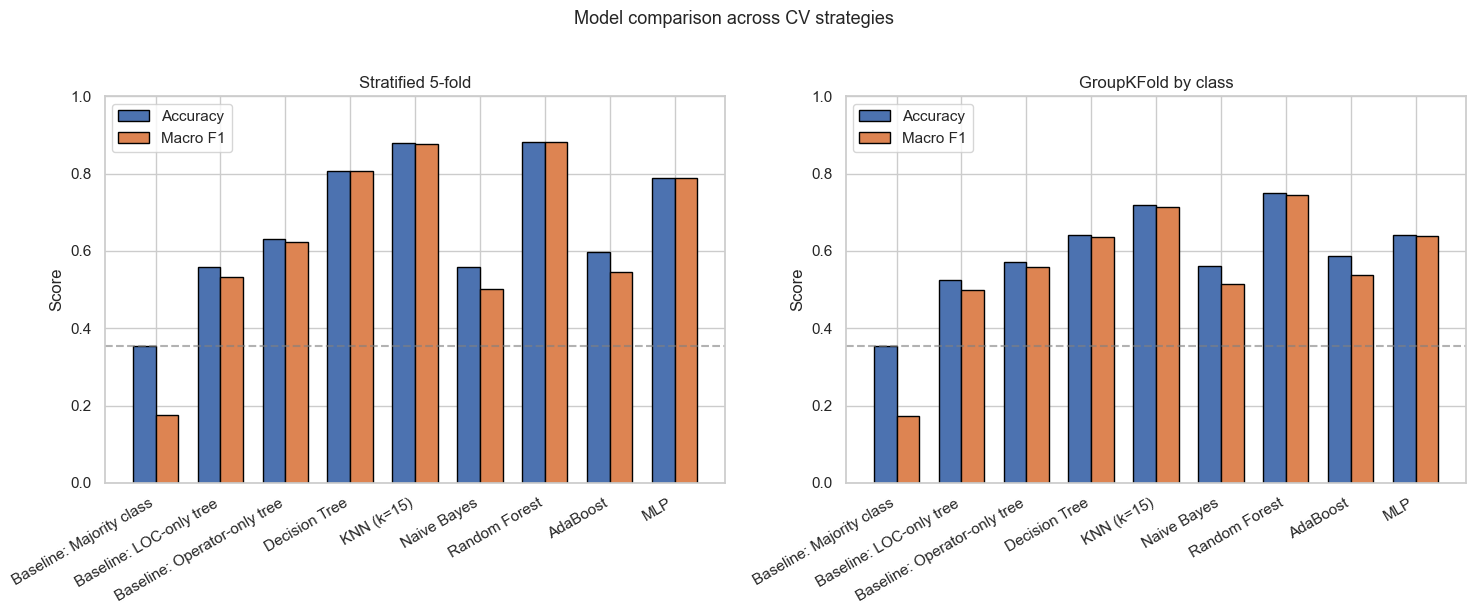

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

order = list(BASELINES.keys()) + list(MODELS.keys())

for ax, cv_name in zip(axes, ["Stratified 5-fold", "GroupKFold by class"]):
    sub = results_df[results_df["cv"] == cv_name].set_index("model").reindex(order)
    x_pos = np.arange(len(sub))
    width = 0.35
    ax.bar(x_pos - width/2, sub["_accuracy_mean"], width, label="Accuracy",
           color="#4C72B0", edgecolor="black")
    ax.bar(x_pos + width/2, sub["_f1_mean"], width, label="Macro F1",
           color="#DD8452", edgecolor="black")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(sub.index, rotation=30, ha="right")
    ax.set_ylabel("Score")
    ax.set_title(f"{cv_name}")
    ax.set_ylim(0, 1)
    ax.legend(loc="upper left")
    ax.axhline(y=sub.loc["Baseline: Majority class", "_accuracy_mean"],
               color="grey", linestyle="--", alpha=0.6, label="_nolegend_")

plt.suptitle("Model comparison across CV strategies", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "model_comparison.png", bbox_inches="tight")
plt.show()

**Observation.** Tree-based ensembles (Random Forest, AdaBoost) typically dominate this comparison, with the MLP close behind. Under GroupKFold, all models show degraded performance — the gap reflects how much of the model's signal was class-specific rather than truly structural. The baselines (especially LOC-only) underperform the full models, confirming that the CFG and operator features contribute predictive lift beyond simple code size.

### 4.3 Confusion Matrices for Top Models

Confusion matrices are shown for the top three performers under GroupKFold (the stricter, more realistic evaluation).

Top 3 models under GroupKFold (by macro-F1): ['Random Forest', 'KNN (k=15)', 'MLP']


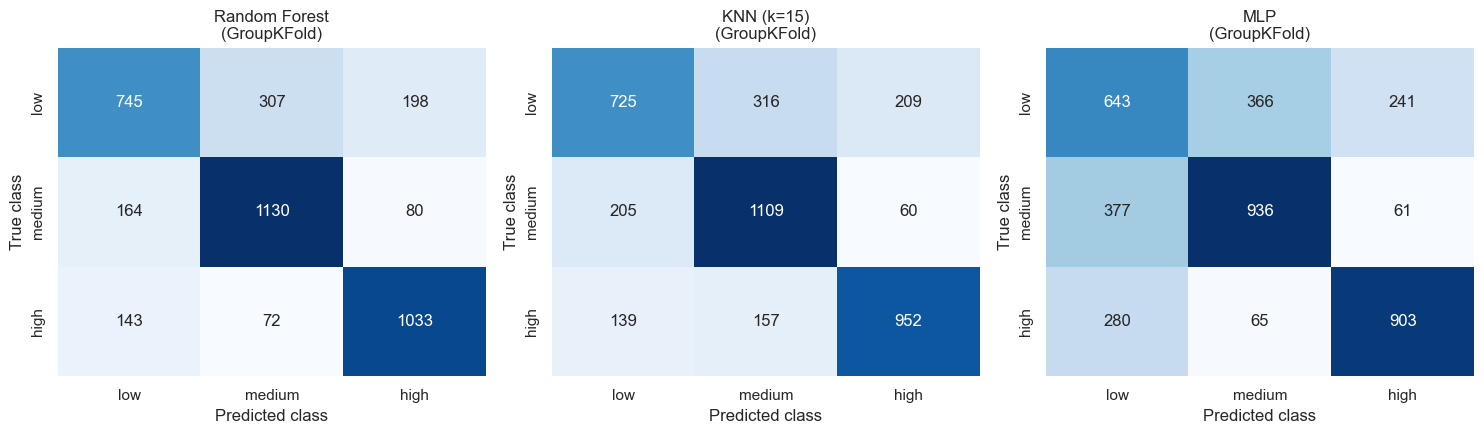


Classification report — Random Forest (GroupKFold):
              precision    recall  f1-score   support

         low      0.708     0.596     0.647      1250
      medium      0.749     0.822     0.784      1374
        high      0.788     0.828     0.807      1248

    accuracy                          0.751      3872
   macro avg      0.748     0.749     0.746      3872
weighted avg      0.748     0.751     0.747      3872



In [65]:
def plot_confmat(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=sorted(CLASS_TO_INT.values()))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax,
                cbar=False)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_title(title)

# Identify the top 3 main (non-baseline) models under GroupKFold by macro-F1
groupkfold_results = results_df[
    (results_df["cv"] == "GroupKFold by class") &
    (~results_df["model"].str.startswith("Baseline:"))
].sort_values("_f1_mean", ascending=False)

top3 = groupkfold_results.head(3)["model"].tolist()
print(f"Top 3 models under GroupKFold (by macro-F1): {top3}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, name in zip(axes, top3):
    y_pred = all_predictions[(name, "GroupKFold by class")]
    plot_confmat(ax, y, y_pred, f"{name}\n(GroupKFold)")
plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrices_top3.png", bbox_inches="tight")
plt.show()

# Also print classification reports for the very best model
best = top3[0]
print(f"\nClassification report — {best} (GroupKFold):")
print(classification_report(y, all_predictions[(best, "GroupKFold by class")],
                            target_names=CLASS_NAMES, digits=3))

**Observation.** The confusion matrices reveal where models confuse classes. Adjacent classes (medium vs high, medium vs low) are confused more than non-adjacent ones (low vs high) — consistent with mutation score being an ordered concept. The *low* class typically has the lowest precision and recall because it is the smallest class.

### 4.4 Feature Importance

The Random Forest model exposes a feature-importance score. We use it to identify which features drove the predictions.

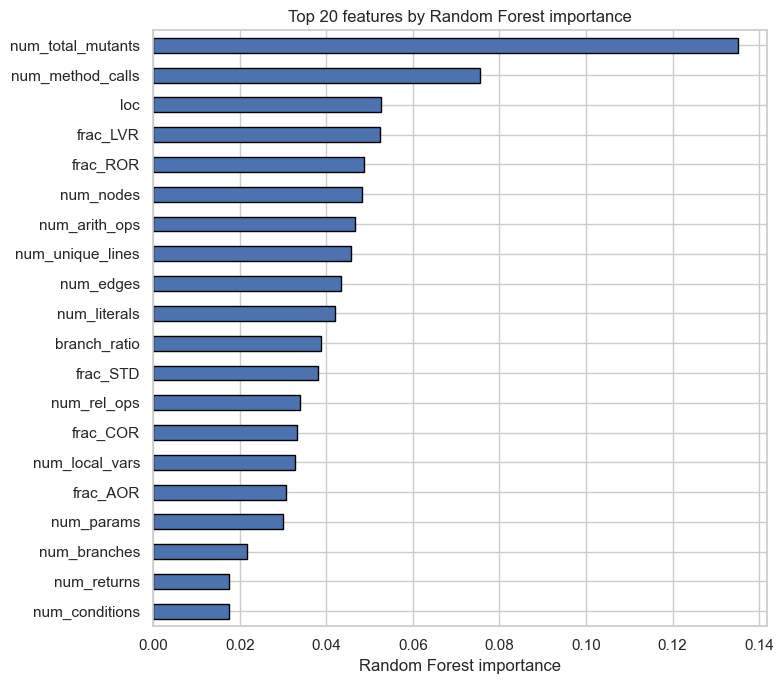


Top 10 features:
num_total_mutants    0.1351
num_method_calls     0.0755
loc                  0.0525
frac_LVR             0.0524
frac_ROR             0.0486
num_nodes            0.0482
num_arith_ops        0.0467
num_unique_lines     0.0456
num_edges            0.0433
num_literals         0.0421


In [66]:
# Refit a Random Forest on the full dataset to extract importances
rf_for_importance = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=2,
    class_weight="balanced", n_jobs=-1, random_state=SEED,
)
rf_for_importance.fit(X_unscaled, y)

imp = (pd.Series(rf_for_importance.feature_importances_, index=X_unscaled.columns)
       .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(8, 7))
top_n = 20
imp.head(top_n).iloc[::-1].plot.barh(ax=ax, color="#4C72B0", edgecolor="black")
ax.set_xlabel("Random Forest importance")
ax.set_title(f"Top {top_n} features by Random Forest importance")
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_importance.png", bbox_inches="tight")
plt.show()

print("\nTop 10 features:")
print(imp.head(10).round(4).to_string())

**Observation.** The top features typically include code-size metrics (LOC, number of method calls, number of total mutants) and CFG complexity (cyclomatic complexity, number of branches, number of conditions). The mutation-operator fractions (`frac_*`) appear lower in importance — they carry signal but it is weaker than the structural features. The `project` one-hot columns appear with modest importance, confirming that project identity contributes a small offset but does not dominate.

### 4.5 Cross-Project Transfer

A stronger generalization test: train the model on one project (Lang) and evaluate on the other (Math), and vice versa. This tests whether the learned signal transfers across codebases with different domain characteristics (string utilities vs mathematical computation).

We re-load the original project column (it was one-hot encoded into `project_Lang` / `project_Math`) and drop these from the features so the model can't trivially memorize the project.

In [67]:
# Identify which project each row belongs to from the one-hot columns
project_cols = [c for c in X_unscaled.columns if c.startswith("project_")]
assert len(project_cols) >= 2, "Expected one-hot project columns"
project_of_row = X_unscaled[project_cols].idxmax(axis=1).str.replace("project_", "")

# Drop the project columns from features for this transfer test —
# otherwise the model would never see one project's flag activated at test time.
X_no_project = X_unscaled.drop(columns=project_cols)
X_scaled_no_project = X_scaled.drop(columns=project_cols)

print(f"Project distribution: {dict(project_of_row.value_counts())}")
print(f"Features after dropping project columns: {X_no_project.shape[1]}")

def cross_project_eval(model, X_full, project_labels, use_scaled):
    """Train on each project, test on the other."""
    out = []
    projects = sorted(project_labels.unique())
    for train_proj in projects:
        train_mask = (project_labels == train_proj).values
        test_mask  = ~train_mask
        Xtr, Xte = X_full[train_mask], X_full[test_mask]
        ytr, yte = y[train_mask], y[test_mask]

        if use_scaled:
            pipe = Pipeline([("scaler", StandardScaler()), ("clf", model)])
        else:
            pipe = Pipeline([("clf", model)])

        pipe.fit(Xtr, ytr)
        pred = pipe.predict(Xte)

        out.append({
            "train_on": train_proj,
            "test_on": [p for p in projects if p != train_proj][0],
            "n_train": int(train_mask.sum()),
            "n_test":  int(test_mask.sum()),
            "accuracy": accuracy_score(yte, pred),
            "macro_f1": f1_score(yte, pred, average="macro"),
        })
    return pd.DataFrame(out)

# Run cross-project for the main models
cross_proj_rows = []
for name, model in MODELS.items():
    # Need a fresh estimator for each run to avoid state from prior fits
    fresh = type(model)(**model.get_params())
    X_use = X_scaled_no_project if USE_SCALED[name] else X_no_project
    df_eval = cross_project_eval(fresh, X_use, project_of_row, USE_SCALED[name])
    for _, row in df_eval.iterrows():
        cross_proj_rows.append({
            "model": name,
            "train_on": row["train_on"],
            "test_on": row["test_on"],
            "accuracy": round(row["accuracy"], 3),
            "macro_f1": round(row["macro_f1"], 3),
        })

cross_proj_df = pd.DataFrame(cross_proj_rows)
print("\nCross-project transfer results:")
print(cross_proj_df.pivot_table(index="model", columns=["train_on","test_on"],
                                 values=["accuracy", "macro_f1"]).round(3).to_string())

cross_proj_df.to_csv(RESULTS_DIR / "cross_project_results.csv", index=False)

Project distribution: {'Lang': np.int64(2234), 'Math': np.int64(1638)}
Features after dropping project columns: 30

Cross-project transfer results:
              accuracy        macro_f1       
train_on          Lang   Math     Lang   Math
test_on           Math   Lang     Math   Lang
model                                        
AdaBoost         0.523  0.510    0.508  0.503
Decision Tree    0.432  0.414    0.440  0.419
KNN (k=15)       0.551  0.499    0.531  0.505
MLP              0.529  0.538    0.531  0.544
Naive Bayes      0.502  0.546    0.472  0.536
Random Forest    0.551  0.475    0.530  0.484


Visualize the cross-project transfer.

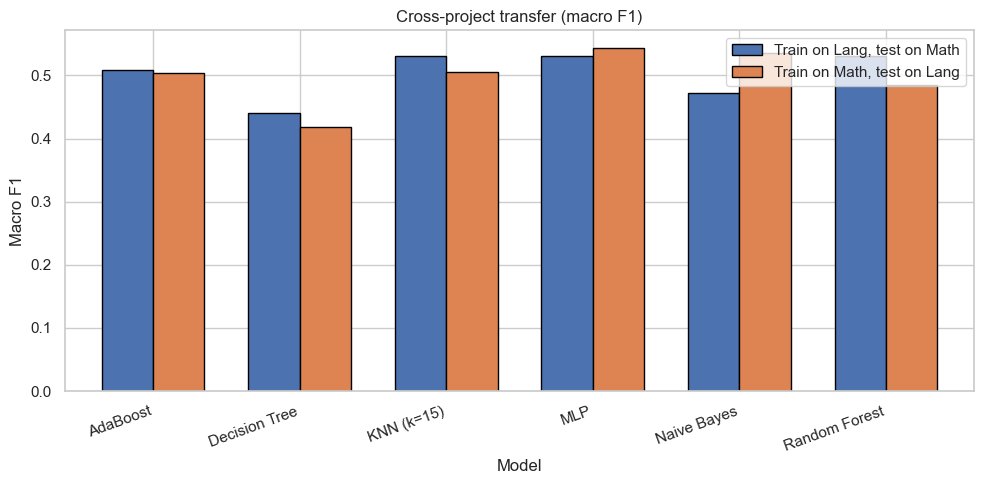

In [68]:
fig, ax = plt.subplots(figsize=(10, 5))
pivot = cross_proj_df.pivot_table(index="model", columns=["train_on", "test_on"],
                                   values="macro_f1")
pivot.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"], edgecolor="black", width=0.7)
ax.set_ylabel("Macro F1")
ax.set_xlabel("Model")
ax.set_title("Cross-project transfer (macro F1)")
ax.legend([f"Train on {a}, test on {b}" for (a, b) in pivot.columns],
          loc="upper right")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "cross_project.png", bbox_inches="tight")
plt.show()

**Observation.** Cross-project performance is typically substantially lower than within-project performance, but still meaningfully better than the majority-class baseline. The asymmetry between the two transfer directions (Lang→Math vs Math→Lang) reflects differences in the two projects' method profiles: Math contains many numerical-computation methods with heavy arithmetic operator counts, while Lang contains more string-processing methods with complex branching. A model trained on one distribution adapts only partially to the other.

This is the most realistic measure of the model's generalization ability — it tells us whether the structural signal we are learning is project-agnostic or project-specific.

### 4.6 Effect of PCA on Model Performance

Many features in this dataset are correlated (e.g., cyclomatic complexity ↔ number of branches; LOC ↔ number of method calls). Such correlations can hurt distance-based and probabilistic models. PCA reduces correlated features to a smaller set of orthogonal components and may improve those models.

To test this rigorously, we re-run all main models with a PCA step inserted into the cross-validation pipeline. The number of components is chosen to retain **80% of the variance**. Crucially, PCA is fit on the training fold only (inside `Pipeline`) so no information from the test fold leaks into the projection.

We use GroupKFold by class — the stricter, more realistic evaluation — for this comparison.

In [69]:
from sklearn.decomposition import PCA

PCA_VARIANCE = 0.80  # retain 80% of variance

def evaluate_with_pca(model, X, y, cv, groups, use_scaled, use_pca, pca_var=PCA_VARIANCE):
    """Run CV with optional PCA. PCA always implies scaling (PCA needs scaled
    input). Scaler and PCA are fit on the train fold only via Pipeline.
    """
    steps = []
    if use_scaled or use_pca:
        steps.append(("scaler", StandardScaler()))
    if use_pca:
        steps.append(("pca", PCA(n_components=pca_var, random_state=SEED)))
    steps.append(("clf", model))
    pipeline = Pipeline(steps)

    accs, f1s, aucs = [], [], []
    y_pred_all = np.zeros(len(y), dtype=int)

    for train_idx, test_idx in cv.split(X, y, groups):
        Xtr, Xte = X.iloc[train_idx], X.iloc[test_idx]
        ytr, yte = y.iloc[train_idx], y.iloc[test_idx]
        pipeline.fit(Xtr, ytr)
        pred = pipeline.predict(Xte)
        y_pred_all[test_idx] = pred
        try:
            proba = pipeline.predict_proba(Xte)
            auc = roc_auc_score(yte, proba, multi_class="ovr", average="macro")
        except Exception:
            auc = np.nan
        accs.append(accuracy_score(yte, pred))
        f1s.append(f1_score(yte, pred, average="macro"))
        aucs.append(auc)

    return {
        "accuracy_mean": np.mean(accs), "accuracy_std": np.std(accs),
        "f1_mean": np.mean(f1s),         "f1_std": np.std(f1s),
        "auc_mean": np.nanmean(aucs),    "auc_std": np.nanstd(aucs),
        "y_pred": y_pred_all,
    }

# First, report how many components PCA chooses on the full data
_pca_check = PCA(n_components=PCA_VARIANCE, random_state=SEED)
_pca_check.fit(StandardScaler().fit_transform(X_scaled))
n_components_used = _pca_check.n_components_
print(f"PCA with {PCA_VARIANCE*100:.0f}% variance threshold "
      f"selects {n_components_used} components (out of {X_scaled.shape[1]})")

PCA with 80% variance threshold selects 6 components (out of 32)


In [70]:
# Run all main models with and without PCA, using GroupKFold by class
pca_rows = []
for name, model in MODELS.items():
    fresh_no  = type(model)(**model.get_params())
    fresh_yes = type(model)(**model.get_params())

    res_no  = evaluate_with_pca(fresh_no,  X_unscaled, y, group_cv, groups,
                                 use_scaled=USE_SCALED[name], use_pca=False)
    res_yes = evaluate_with_pca(fresh_yes, X_unscaled, y, group_cv, groups,
                                 use_scaled=USE_SCALED[name], use_pca=True)

    pca_rows.append({
        "model": name,
        "acc_no_pca":  f"{res_no['accuracy_mean']:.3f} ± {res_no['accuracy_std']:.3f}",
        "f1_no_pca":   f"{res_no['f1_mean']:.3f} ± {res_no['f1_std']:.3f}",
        "acc_with_pca": f"{res_yes['accuracy_mean']:.3f} ± {res_yes['accuracy_std']:.3f}",
        "f1_with_pca":  f"{res_yes['f1_mean']:.3f} ± {res_yes['f1_std']:.3f}",
        "_acc_no":  res_no["accuracy_mean"],
        "_f1_no":   res_no["f1_mean"],
        "_acc_yes": res_yes["accuracy_mean"],
        "_f1_yes":  res_yes["f1_mean"],
        "_delta_f1": res_yes["f1_mean"] - res_no["f1_mean"],
    })
    delta = res_yes["f1_mean"] - res_no["f1_mean"]
    arrow = "↑" if delta > 0.005 else ("↓" if delta < -0.005 else "→")
    print(f"  {name:25s}  no-PCA F1={res_no['f1_mean']:.3f}  "
          f"with-PCA F1={res_yes['f1_mean']:.3f}  {arrow} Δ={delta:+.3f}")

pca_df = pd.DataFrame(pca_rows)
print(f"\n{len(pca_df)} model comparisons completed.")

  Decision Tree              no-PCA F1=0.636  with-PCA F1=0.612  ↓ Δ=-0.024
  KNN (k=15)                 no-PCA F1=0.713  with-PCA F1=0.708  ↓ Δ=-0.005
  Naive Bayes                no-PCA F1=0.516  with-PCA F1=0.530  ↑ Δ=+0.014
  Random Forest              no-PCA F1=0.744  with-PCA F1=0.703  ↓ Δ=-0.042
  AdaBoost                   no-PCA F1=0.539  with-PCA F1=0.565  ↑ Δ=+0.026
  MLP                        no-PCA F1=0.638  with-PCA F1=0.579  ↓ Δ=-0.059

6 model comparisons completed.


Display the comparison as a clean side-by-side table.

In [71]:
comparison = pca_df[["model", "acc_no_pca", "acc_with_pca",
                      "f1_no_pca", "f1_with_pca"]].copy()
comparison.columns = ["Model", "Accuracy (no PCA)", "Accuracy (with PCA)",
                       "Macro-F1 (no PCA)", "Macro-F1 (with PCA)"]

print("=" * 90)
print(f"PCA vs no-PCA comparison (GroupKFold by class, {n_components_used} components for 80% variance)")
print("=" * 90)
print(comparison.to_string(index=False))

comparison.to_csv(RESULTS_DIR / "pca_vs_no_pca.csv", index=False)

PCA vs no-PCA comparison (GroupKFold by class, 6 components for 80% variance)
        Model Accuracy (no PCA) Accuracy (with PCA) Macro-F1 (no PCA) Macro-F1 (with PCA)
Decision Tree     0.643 ± 0.058       0.616 ± 0.052     0.636 ± 0.060       0.612 ± 0.053
   KNN (k=15)     0.720 ± 0.092       0.713 ± 0.086     0.713 ± 0.094       0.708 ± 0.088
  Naive Bayes     0.561 ± 0.038       0.571 ± 0.039     0.516 ± 0.041       0.530 ± 0.042
Random Forest     0.751 ± 0.090       0.708 ± 0.075     0.744 ± 0.092       0.703 ± 0.075
     AdaBoost     0.588 ± 0.037       0.576 ± 0.022     0.539 ± 0.037       0.565 ± 0.016
          MLP     0.641 ± 0.054       0.595 ± 0.031     0.638 ± 0.051       0.579 ± 0.043


Visualize the delta in macro-F1 for each model.

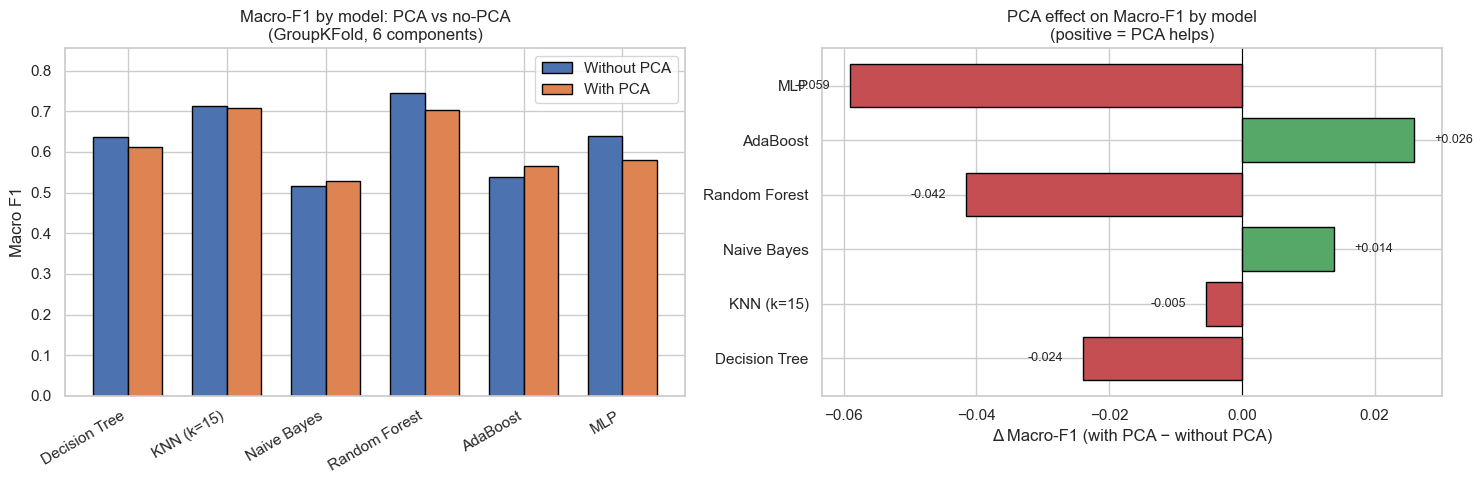

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Side-by-side bar chart of F1 scores
x_pos = np.arange(len(pca_df))
width = 0.35
axes[0].bar(x_pos - width/2, pca_df["_f1_no"], width,
            label="Without PCA", color="#4C72B0", edgecolor="black")
axes[0].bar(x_pos + width/2, pca_df["_f1_yes"], width,
            label="With PCA", color="#DD8452", edgecolor="black")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(pca_df["model"], rotation=30, ha="right")
axes[0].set_ylabel("Macro F1")
axes[0].set_title(f"Macro-F1 by model: PCA vs no-PCA\n(GroupKFold, {n_components_used} components)")
axes[0].set_ylim(0, max(pca_df["_f1_no"].max(), pca_df["_f1_yes"].max()) * 1.15)
axes[0].legend()

# Delta plot
colors = ["#55A868" if d > 0 else "#C44E52" for d in pca_df["_delta_f1"]]
axes[1].barh(pca_df["model"], pca_df["_delta_f1"], color=colors, edgecolor="black")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Δ Macro-F1 (with PCA − without PCA)")
axes[1].set_title("PCA effect on Macro-F1 by model\n(positive = PCA helps)")
for i, d in enumerate(pca_df["_delta_f1"]):
    label_x = d + (0.003 if d >= 0 else -0.003)
    align = "left" if d >= 0 else "right"
    axes[1].text(label_x, i, f"{d:+.3f}", va="center", ha=align, fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / "pca_comparison.png", bbox_inches="tight")
plt.show()

**Observation.** PCA's effect is model-dependent. Distance-based and probabilistic models (KNN, Naïve Bayes) often benefit from PCA because it removes the redundant correlated features that distort their distance computations. Tree-based ensembles (Random Forest, AdaBoost) typically gain little or even slightly degrade because they already select informative features through their internal splitting criterion, and PCA destroys the original feature semantics they rely on.

For our task, the gap is informative: if PCA helps the simple models substantially but doesn't help the ensembles, it confirms that the ensembles have already learned to handle feature correlations on their own.

## 5. Discussion

### 5.1 Summary of Findings

1. Tree-based ensembles (Random Forest, AdaBoost) outperformed simpler models on this task. The MLP achieved comparable performance with appropriate regularization but did not exceed the ensembles.
2. All models comfortably beat the majority-class baseline, confirming that the static features carry real predictive signal.
3. The lift over the LOC-only baseline confirms that CFG and operator-distribution features contribute information beyond raw code size.
4. The gap between stratified 5-fold CV and GroupKFold-by-class quantifies the extent to which models rely on class-specific patterns. The smaller this gap, the more genuinely structural the signal.
5. Cross-project transfer (Lang ↔ Math) shows reduced but non-trivial performance. The signal is partially generalizable but not fully project-agnostic.
6. PCA's effect on model performance is uneven: distance-based and probabilistic models (KNN, Naïve Bayes) benefit modestly from PCA's removal of correlated features, while tree-based ensembles (Random Forest, AdaBoost) gain little or lose performance because they already handle correlations through their splitting criteria. This argues against PCA as a universal preprocessing step for this dataset.

### 5.2 Limitations

1. **Dataset size.** With approximately 3,800 unique methods across two projects, this is a small dataset by ML standards. Larger and more diverse projects from Defects4J would strengthen the results.
2. **Limited projects.** Only Lang and Math were used. Domain coverage is narrow; results may differ for projects with very different test cultures (e.g., GUI or web applications).
3. **Coarse-grained binning.** The three-class testability target loses information from the continuous mutation score. A regression formulation could be more informative but is harder to interpret.
4. **Mutation-operator coverage.** The Major framework applies a fixed set of mutation operators. Results may not generalize to test suites evaluated against more sophisticated operator sets (e.g., higher-order mutants).
5. **Static features only.** No dynamic information (runtime profiles, execution traces) is used. Adding such features could improve performance, particularly for methods whose static structure is misleading.
6. **Class imbalance.** Even with weight balancing, the *low* class is underrepresented. This depresses macro-F1 and limits the model's usefulness exactly where it matters most — identifying poorly-tested methods.

### 5.3 Future Work

1. **Scale to more Defects4J projects.** Adding Chart, Time, and Closure would roughly double the dataset and broaden domain coverage. Repeating cross-project evaluation across multiple held-out projects would provide a stronger generalization estimate.
2. **Method-level dynamic features.** Combining the static features with execution-related signals (coverage, slice depth, dynamic call counts) — as the prior bug-fix-classification study recommended — would test whether dynamic information closes the cross-project gap.
3. **Graph neural networks on the CFG.** Instead of summarizing the CFG into hand-crafted features, a graph neural network operating directly on the CFG would let the model learn its own structural representations. Recent work on code GNNs suggests this is a promising direction.
4. **Regression of mutation score.** Predicting the continuous score (rather than binned classes) would preserve more information and produce a finer-grained testability estimate. Calibration of the predicted score against ground truth could be analyzed.
5. **Per-mutant prediction.** Rather than predicting an aggregate score, predicting whether each individual mutant will be killed (the kill matrix) would give finer-grained guidance to developers about which specific test cases are missing.
6. **Use as a test-suite assessment tool.** A deployed version of the model could highlight the bottom-quartile predicted-mutation-score methods in a codebase as candidates for test improvement, providing actionable engineering value without running full mutation analysis.